# 01 — Behavioural Goal 1: the planned family, then the data behind it

**What this notebook is.** The confirmatory freeze for Results 7.2, followed by everything one needs to believe it: the raw matrices, per-condition distributions, both arms, the same matrix under Friedman + pairwise Wilcoxon, and model-based checks (ordinal GEE, random-intercept LMM) that adjust for arm, session position and task.

**Frozen composites** (planned, \(8-x\) on reverse items): `credibility` = mean(reliable, 8−false, 8−made_up); `manipulation` = mean(pushing, manipulate); `notice` = mean(brands, sponsored); `trust` = single item *"I felt I could trust the chatbot"*. Person is the unit. Planned \(D\) weights match EEG Dataset A: any ad − no ad, implicit − explicit, early − late.

**How to read the p's.** Holm \(p\) is the Holm-adjusted paired \(t\) within outcome (three contrasts). Wilcoxon \(p\) is raw. Anything in §5 onward is a check on the same numbers, not a second confirmatory family.

Sections: 1 data · 2 planned \(D\) · 2b localisation (post-hoc) · 3 recall · 4 Friedman / pairwise · 5 models · 6 trust deep dive · 7 checked / not checked.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
WALTER = HERE / "analysis" / "walter"
for p in (WALTER, WALTER / "behavioural" / "stats", WALTER / "combos"):
    sys.path.insert(0, str(p))
import statkit as sk
import viz
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
GOLD = WALTER / "behavioural" / "outputs" / "gold"
import run_confirmatory as rc
summary = rc.run()
CONF = rc.OUT
SWEEP = WALTER / "behavioural" / "outputs" / "exploratory"
ORD = WALTER / "behavioural" / "outputs" / "ordinal"
c = pd.read_csv(GOLD / "condition_features.csv")
person = pd.read_csv(GOLD / "person_features.csv")
ads = pd.read_csv(GOLD / "advertisement_features.csv")
PRIMARY = ["trust", "credibility", "manipulation", "notice"]
print(c.shape, "condition rows;", c.experiment_id.nunique(), "people;", dict(c.drop_duplicates("experiment_id").arm.value_counts()))

(270, 69) condition rows; 54 people; {'crowd': np.int64(36), 'lab': np.int64(18)}


## 1. The data

One row per person × condition. Four primary outcomes, all on the 1–7 scale. First the numbers, then the shape.

trust              credibility              manipulation              notice             
                mean   std median        mean   std median         mean   std median   mean   std median
no ad           5.37  1.63    6.0        6.04  1.15   6.33         2.73  1.97   2.00   2.96  1.63    3.0
implicit early  4.93  1.80    5.0        5.69  1.35   6.00         3.94  2.10   4.00   4.56  1.89    4.5
implicit late   5.28  1.58    6.0        6.04  1.09   6.50         3.45  1.98   3.50   4.36  1.89    4.0
explicit early  4.69  1.91    5.0        5.78  1.30   6.00         4.65  1.95   5.00   5.77  1.74    6.5
explicit late   5.22  1.76    6.0        6.08  0.93   6.33         3.97  2.06   3.75   5.45  1.94    6.5

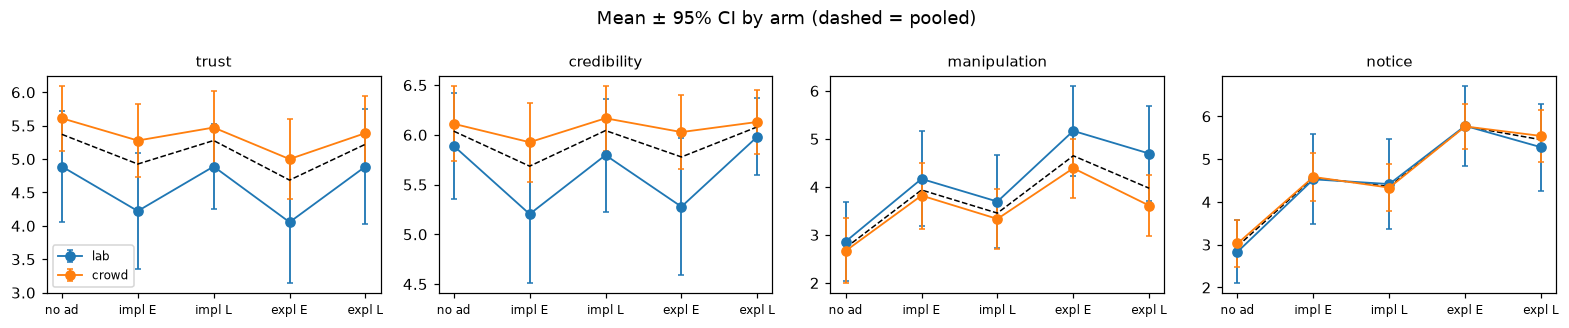

In [2]:
desc = (c.groupby("condition")[PRIMARY].agg(["mean", "std", "median"]).reindex(sk.CONDITIONS).round(2))
desc.index = [sk.LABEL[x] for x in desc.index]
display(desc)
display(viz.arm_profiles(c, PRIMARY)); plt.close()

Each primary, three views: the full 54 × 5 matrix sorted by the person's any-ad difference (blue squares mark lab people), the jittered answers per condition with mean and median, and the arm profiles. **Trust**: both *late* cells sit on the no-ad line; both *early* cells sit below it; same shape in both arms, lab lower throughout.

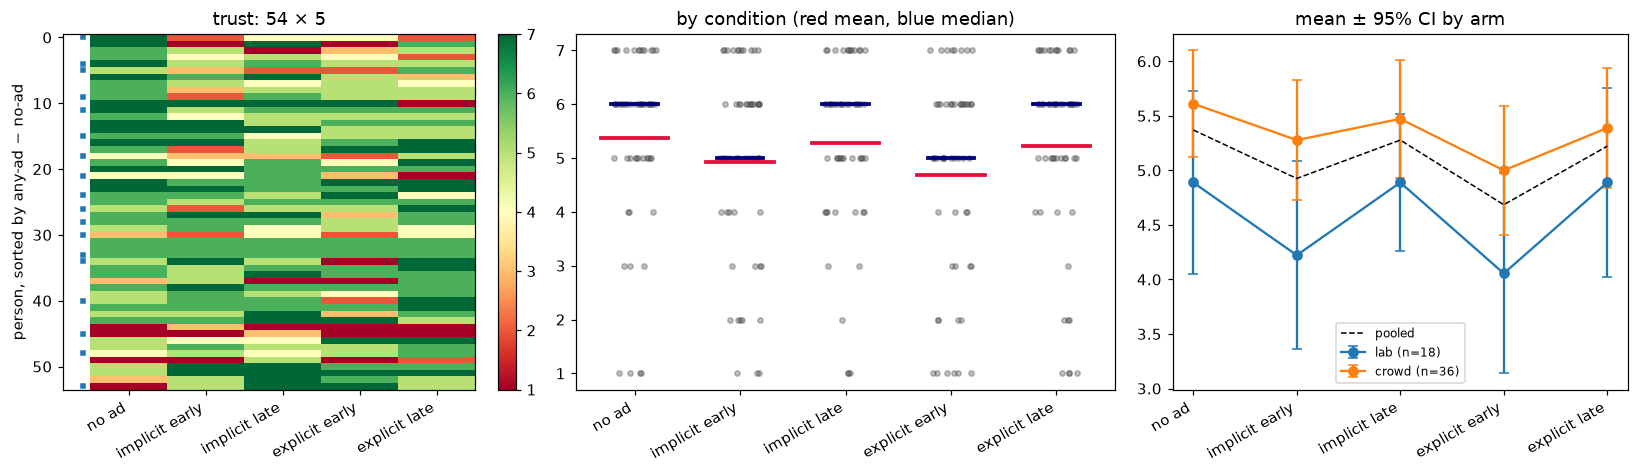

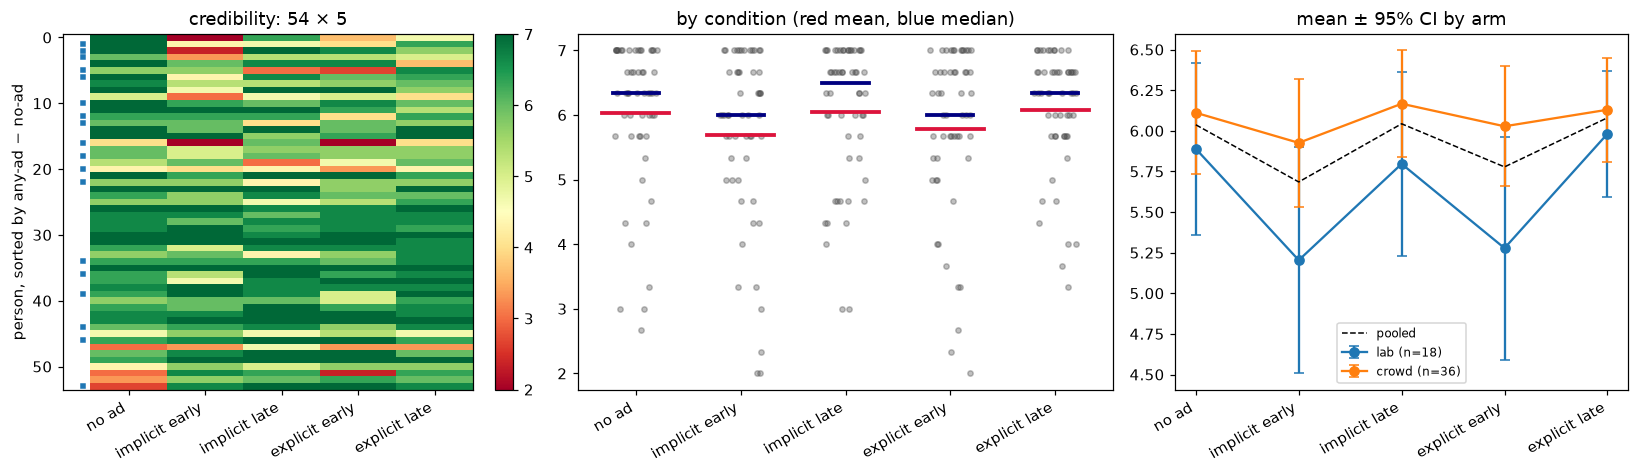

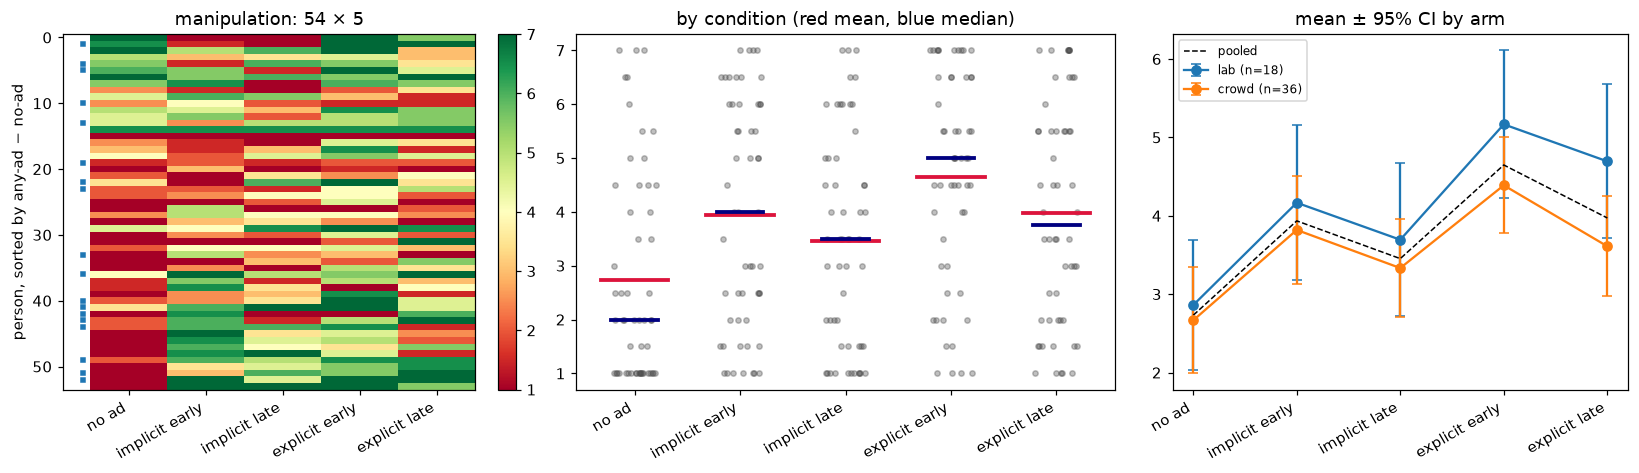

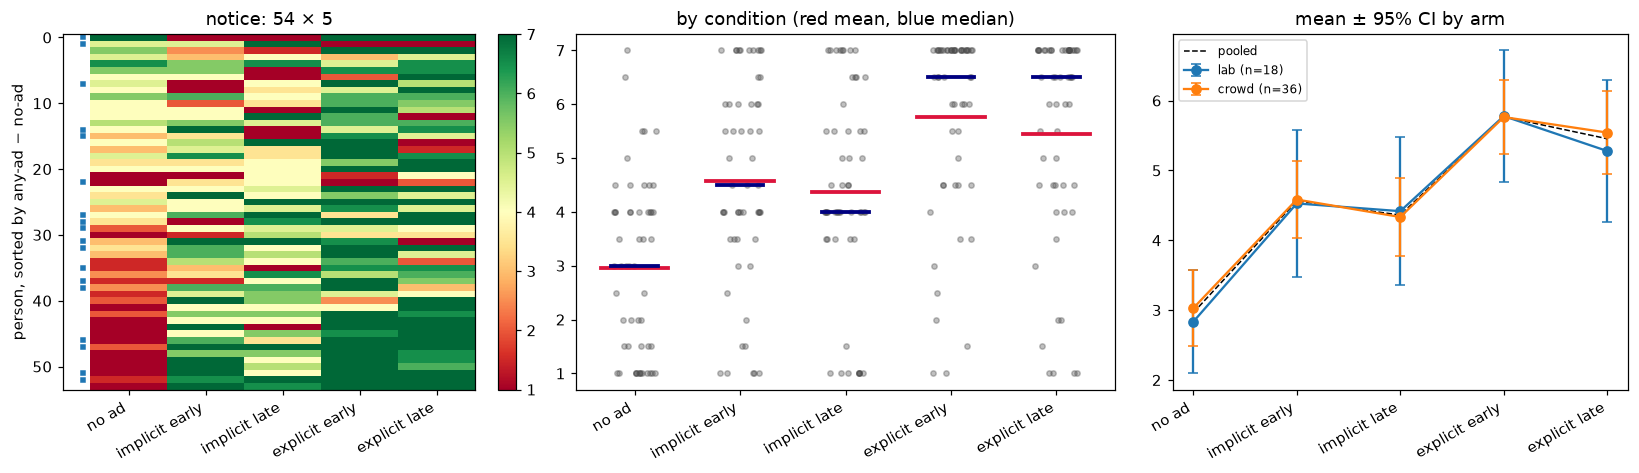

In [3]:
for o in PRIMARY:
    display(viz.overview(c, o)); plt.close()

Likert composition per condition. Ceiling matters: about a fifth of no-ad trust answers are 7, and a person at 7 can only move down.

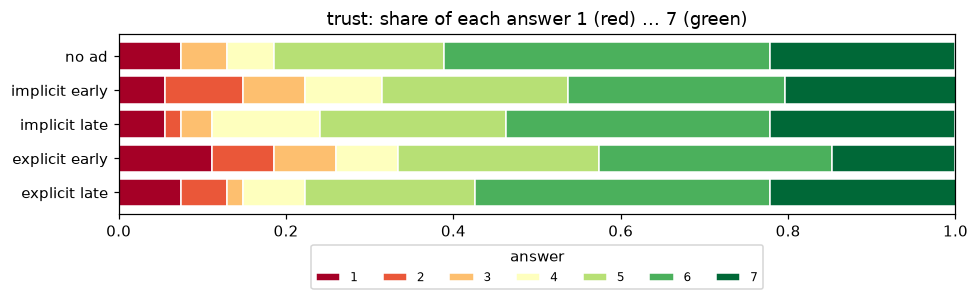

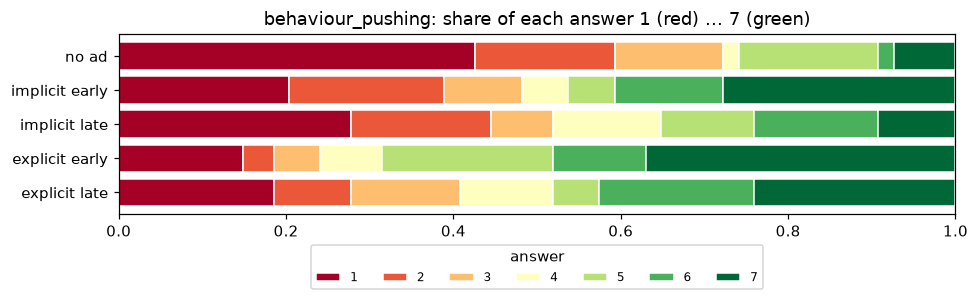

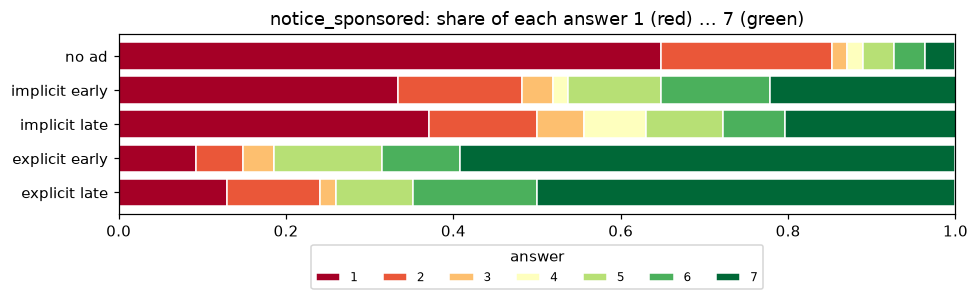

In [4]:
for o in ["trust", "behaviour_pushing", "notice_sponsored"]:
    display(viz.likert_stack(c, o)); plt.close()

## 2. Planned \(D_i\) — the confirmatory table

Paired \(t\) primary (mean, 95% CI, \(d_z\)), Wilcoxon alongside, Holm within outcome. Red = Holm < .05.

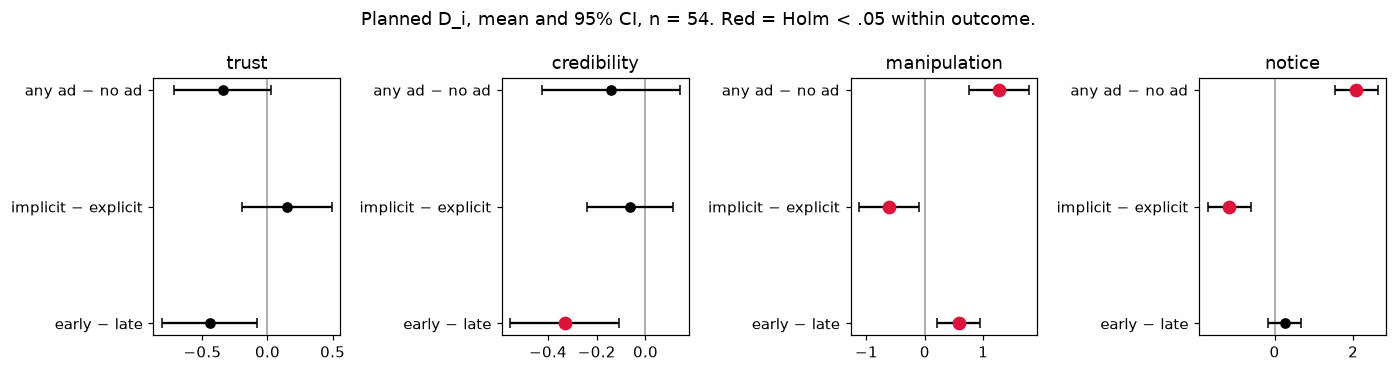

,outcome,contrast_label,n,mean,ci95_lo,ci95_hi,dz,p_raw,p_holm,holm_sig,p_wilcoxon
0,trust,any ad − no ad,54,-0.343000,-0.714000,0.029000,-0.246000,0.076000,0.153000,False,0.016000
1,trust,implicit − explicit,54,0.148000,-0.198000,0.494000,0.114000,0.405000,0.405000,False,0.384000
2,trust,early − late,54,-0.444000,-0.811000,-0.078000,-0.324000,0.021000,0.063000,False,0.026000
3,credibility,any ad − no ad,54,-0.140000,-0.424000,0.143000,-0.132000,0.336000,0.673000,False,0.039000
4,credibility,implicit − explicit,54,-0.065000,-0.241000,0.112000,-0.098000,0.475000,0.673000,False,0.278000
5,credibility,early − late,54,-0.330000,-0.554000,-0.107000,-0.394000,0.005000,0.016000,True,0.007000
6,manipulation,any ad − no ad,54,1.271000,0.757000,1.785000,0.660000,0.000000,0.000000,True,0.000000
7,manipulation,implicit − explicit,54,-0.616000,-1.128000,-0.104000,-0.321000,0.022000,0.022000,True,0.022000
8,manipulation,early − late,54,0.579000,0.206000,0.951000,0.414000,0.004000,0.007000,True,0.004000
9,notice,any ad − no ad,54,2.074000,1.528000,2.620000,1.013000,0.000000,0.000000,True,0.000000


In [5]:
conf = pd.read_csv(CONF / "confirmatory_planned_D.csv")
surv = conf[conf.family == "surveys"]
display(viz.forest_D(surv, PRIMARY, "Planned D_i, mean and 95% CI, n = 54. Red = Holm < .05 within outcome.")); plt.close()
display(surv[["outcome", "contrast_label", "n", "mean", "ci95_lo", "ci95_hi", "dz", "p_raw", "p_holm", "holm_sig", "p_wilcoxon"]].round(3).style.apply(
    lambda r: ["background-color: #ffe0e0" if r.holm_sig else "" for _ in r], axis=1))

Within-person differences behind each cell. The title of each panel counts people who went down / stayed / went up.

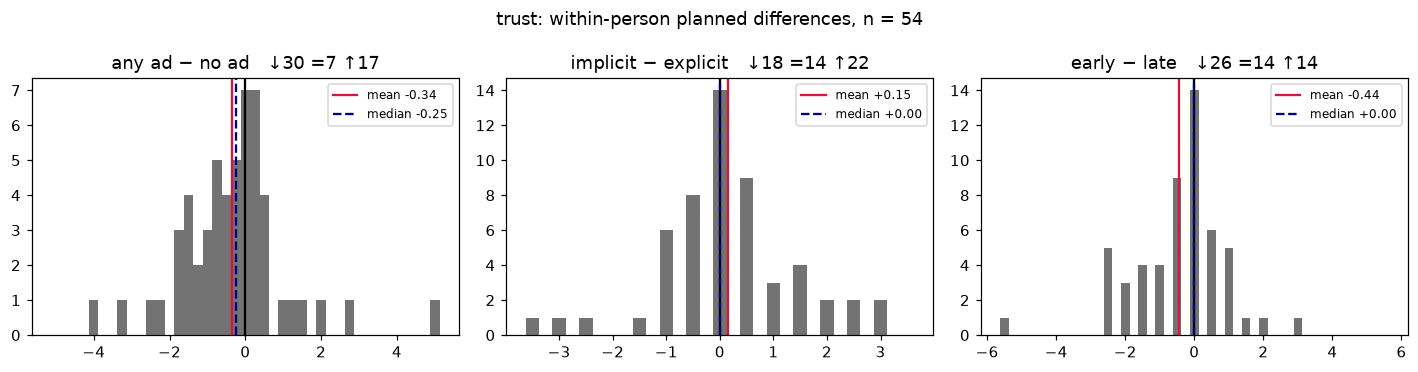

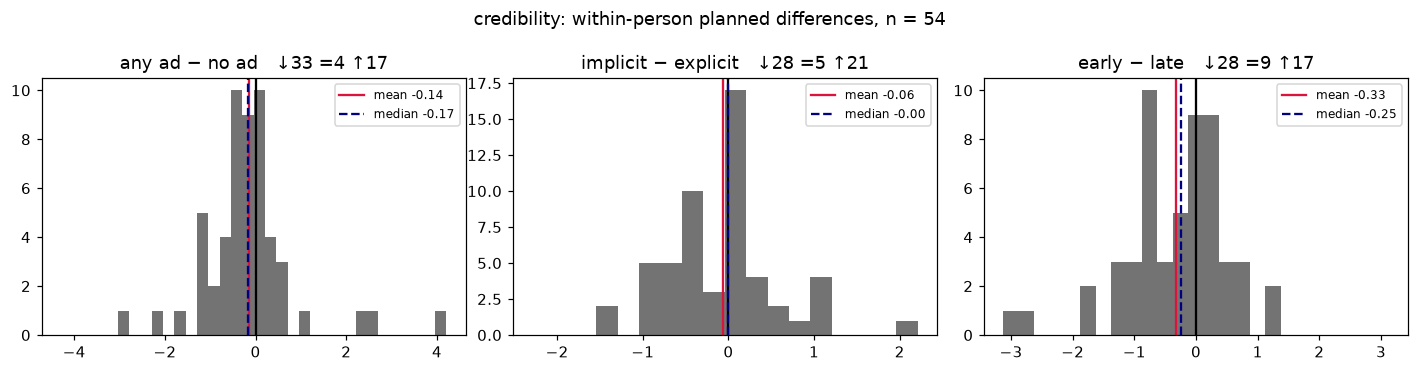

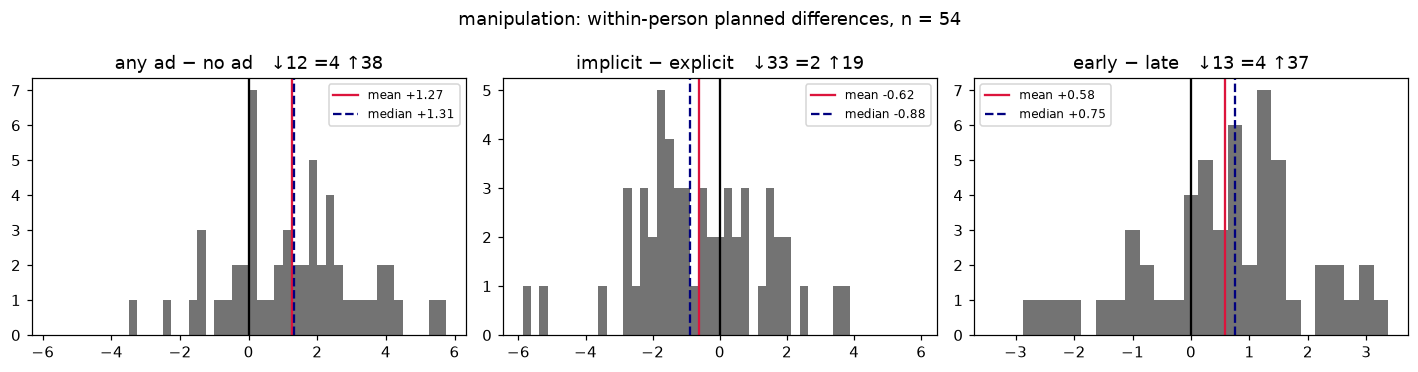

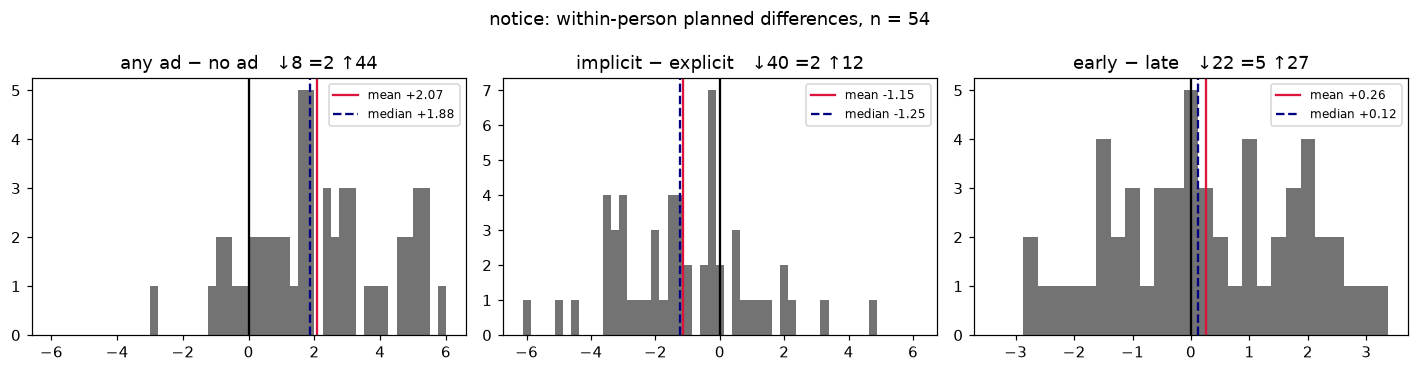

In [6]:
for o in PRIMARY:
    display(viz.d_histograms(c, o)); plt.close()

## 2b. Localisation (post-hoc): each ad condition vs no ad

Second stream. The planned contrasts answer *did ads / format / timing matter*; this answers *which ad condition moved the outcome*. Same paired \(t\) + Wilcoxon machinery, Holm across the four comparisons within outcome. Post-hoc by construction: report it with the family size, never as the confirmatory result. Katerina's omnibus + pairwise stream (Friedman over the conditions, all 10 pairs) is the other half of this and lives in notebook 02 §5 until her version lands on Gold.

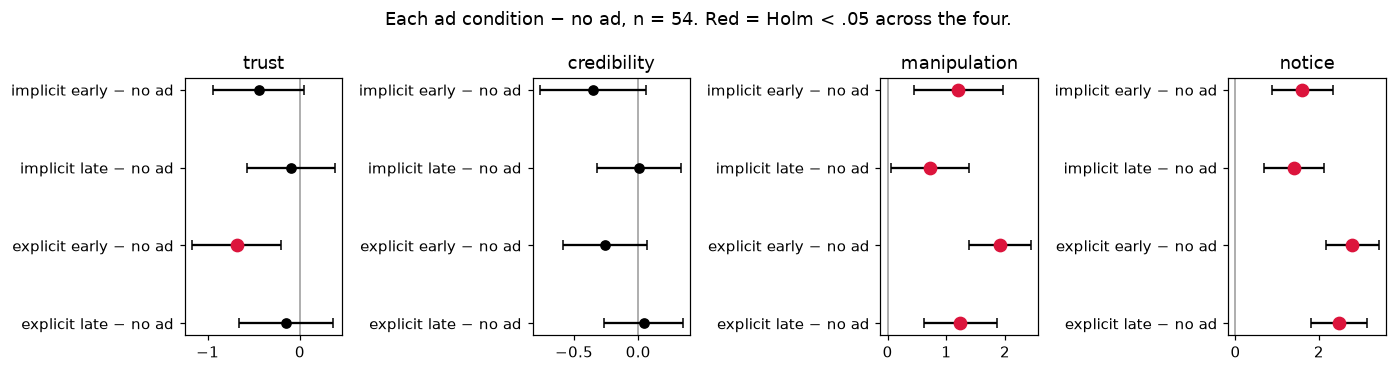

,outcome,contrast_label,mean,ci95_lo,ci95_hi,dz,p_raw,p_holm,holm_sig,p_wilcoxon
0,trust,implicit early − no ad,-0.444000,-0.938000,0.049000,-0.240000,0.083000,0.250000,False,0.125000
1,trust,implicit late − no ad,-0.093000,-0.568000,0.383000,-0.052000,0.704000,1.000000,False,0.535000
2,trust,explicit early − no ad,-0.685000,-1.171000,-0.200000,-0.376000,0.008000,0.031000,True,0.003000
3,trust,explicit late − no ad,-0.148000,-0.657000,0.361000,-0.078000,0.571000,1.000000,False,0.894000
4,credibility,implicit early − no ad,-0.352000,-0.767000,0.064000,-0.226000,0.103000,0.411000,False,0.065000
5,credibility,implicit late − no ad,0.006000,-0.324000,0.337000,0.005000,0.971000,1.000000,False,0.878000
6,credibility,explicit early − no ad,-0.259000,-0.585000,0.066000,-0.212000,0.125000,0.411000,False,0.040000
7,credibility,explicit late − no ad,0.043000,-0.263000,0.350000,0.038000,0.783000,1.000000,False,0.910000
8,manipulation,implicit early − no ad,1.204000,0.442000,1.965000,0.422000,0.003000,0.006000,True,0.004000
9,manipulation,implicit late − no ad,0.722000,0.052000,1.393000,0.287000,0.039000,0.039000,True,0.017000


In [7]:
ph = pd.read_csv(CONF / "posthoc_vs_control.csv")
display(viz.forest_D(ph[ph.outcome.isin(PRIMARY)], PRIMARY, "Each ad condition − no ad, n = 54. Red = Holm < .05 across the four.")); plt.close()
display(ph[ph.outcome.isin(PRIMARY)][["outcome", "contrast_label", "mean", "ci95_lo", "ci95_hi", "dz", "p_raw", "p_holm", "holm_sig", "p_wilcoxon"]].round(3).style.apply(
    lambda r: ["background-color: #ffe0e0" if r.holm_sig else "" for _ in r], axis=1))

## 2c. Assumptions and engine concordance

The paired \(t\) assumes approximate normality of the person-level **differences** \(D_i\), not of the raw Likert scores (those are integers on 1–7 and fail Shapiro in 20/20 condition cells by construction). `stats/run_assumptions.py` → `outputs/assumptions/`:

- Shapiro–Wilk, skew, kurtosis, and a QQ grid on every planned \(D_i\); 7/16 cells reject at .05, all in trust / credibility (heavy tails from a few people, kurtosis up to 5.6). Manipulation, notice, recall are close to normal.
- Does the engine matter? Paired \(t\) (Holm), Wilcoxon (Holm), sign test (Holm), and a 10,000-resample bootstrap percentile CI on the same \(D_i\). Bootstrap CI width is within 3 % of the \(t\) CI in every cell, so the \(t\) interval is not misled by the tails at \(n = 54\). 14/16 planned cells agree across all engines; the two that do not are both **trust** (any ad − no ad: \(t\) Holm .15 vs Wilcoxon Holm .048; early − late: .063 vs .052), and there the nonparametric result is itself at the boundary.
- Katerina's design on Gold (10 pairs × 4 primaries, Holm-10 within outcome): paired \(t\) and Wilcoxon agree in 38/40 cells; the two Wilcoxon-only cells are trust no ad − explicit early (.029 vs .078) and credibility implicit early − explicit late (.041 vs .054). No \(t\)-only cell.

Pre-testing normality and then switching statistic is not the decision rule (Rochon, Gatignol & Kimmel 2012; Zimmerman 2004). The paired \(t\) stays primary as Methods states; the table below is the sensitivity report, and the two trust cells are named as engine-sensitive in the trust paragraph.

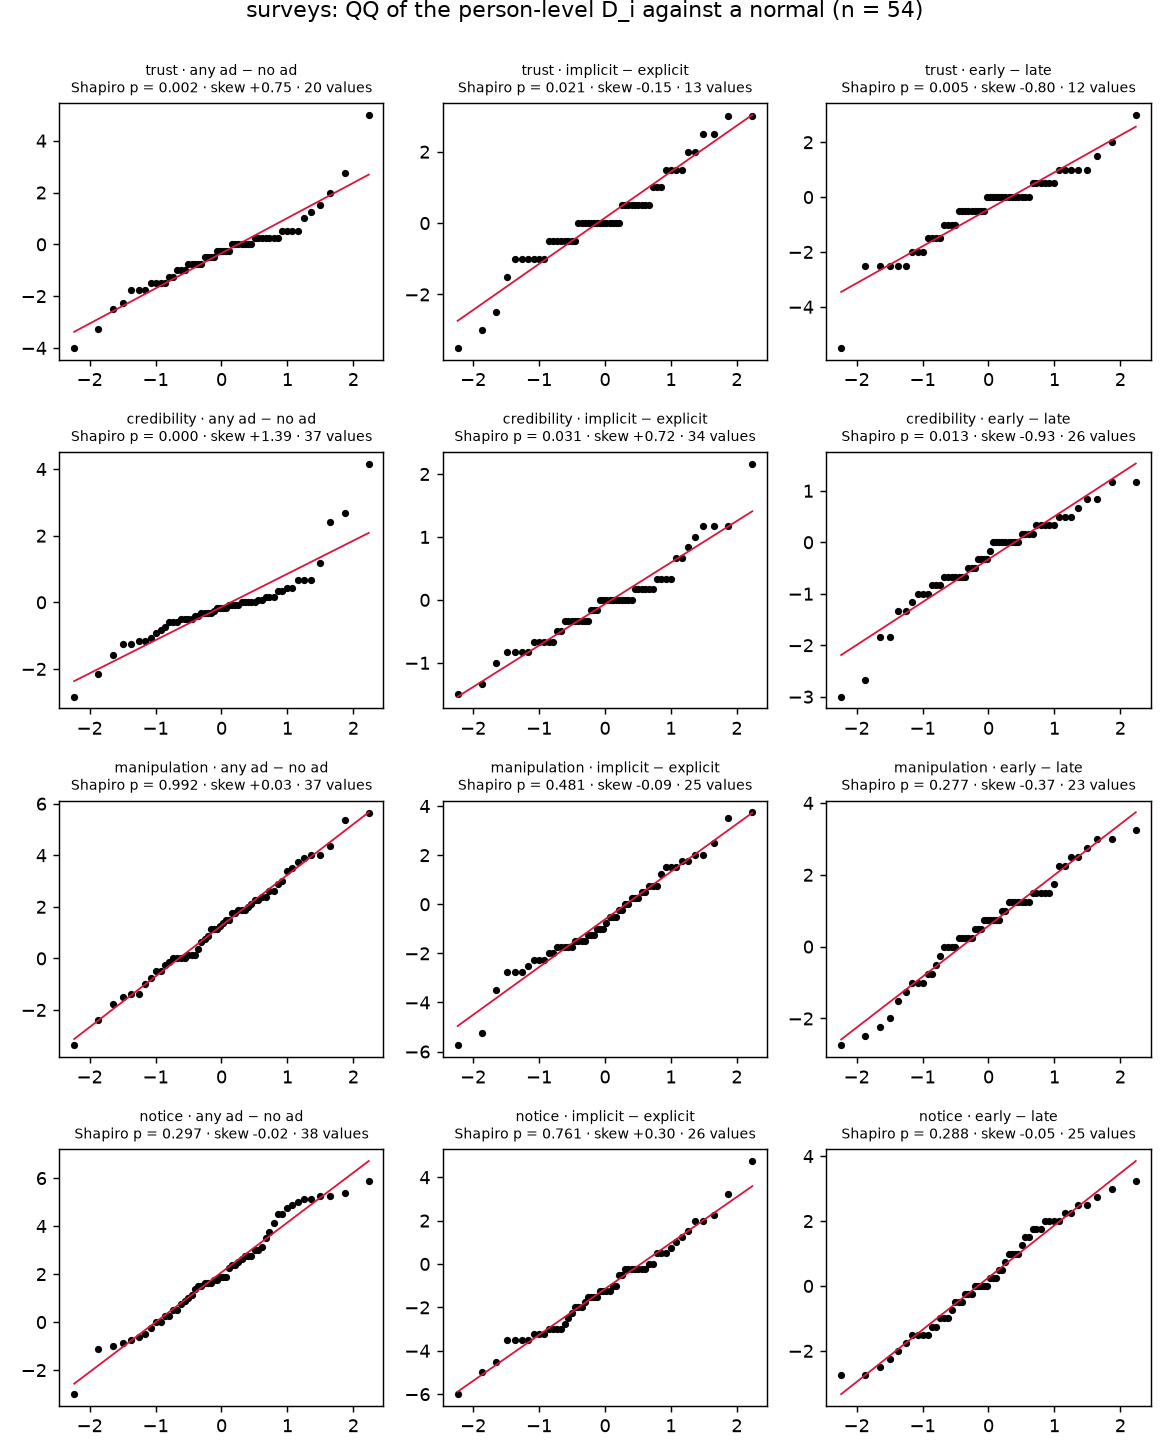

,outcome,contrast_label,n_unique,skew,excess_kurtosis,shapiro_p,t_ci_lo,t_ci_hi,boot_ci_lo,boot_ci_hi,p_t_holm,p_wilcoxon_holm,p_sign_holm,engines_agree
0,trust,any ad − no ad,20,0.755000,3.939000,0.002000,-0.714000,0.029000,-0.699000,0.032000,0.153000,0.048000,0.237000,False
1,trust,implicit − explicit,13,-0.151000,1.107000,0.021000,-0.198000,0.494000,-0.194000,0.491000,0.405000,0.384000,0.636000,True
2,trust,early − late,12,-0.797000,2.678000,0.005000,-0.811000,-0.078000,-0.815000,-0.093000,0.063000,0.052000,0.237000,False
7,credibility,any ad − no ad,37,1.385000,5.640000,0.000000,-0.424000,0.143000,-0.407000,0.148000,0.673000,0.078000,0.099000,True
8,credibility,implicit − explicit,34,0.723000,1.665000,0.031000,-0.241000,0.112000,-0.235000,0.111000,0.673000,0.278000,0.392000,True
9,credibility,early − late,26,-0.928000,1.599000,0.013000,-0.554000,-0.107000,-0.559000,-0.120000,0.016000,0.020000,0.270000,True
14,manipulation,any ad − no ad,37,0.029000,-0.149000,0.992000,0.757000,1.785000,0.759000,1.782000,0.000000,0.000000,0.001000,True
15,manipulation,implicit − explicit,25,-0.085000,0.445000,0.481000,-1.128000,-0.104000,-1.139000,-0.106000,0.022000,0.022000,0.070000,True
16,manipulation,early − late,23,-0.368000,-0.020000,0.277000,0.206000,0.951000,0.199000,0.935000,0.007000,0.007000,0.002000,True
21,notice,any ad − no ad,38,-0.019000,-0.543000,0.297000,1.528000,2.620000,1.542000,2.623000,0.000000,0.000000,0.000000,True


In [8]:
ASSUMP = CONF.parent / "assumptions"
display(Image(ASSUMP / "qq_planned_D.png"))
asm = pd.read_csv(ASSUMP / "assumptions_planned_D.csv")
cols = ["outcome", "contrast_label", "n_unique", "skew", "excess_kurtosis", "shapiro_p", "t_ci_lo", "t_ci_hi", "boot_ci_lo", "boot_ci_hi", "p_t_holm", "p_wilcoxon_holm", "p_sign_holm", "engines_agree"]
display(asm[asm.family.isin(["surveys", "recall"])][cols].round(3).style.apply(lambda r: ["background-color: #fff3cd" if not r.engines_agree else "" for _ in r], axis=1))

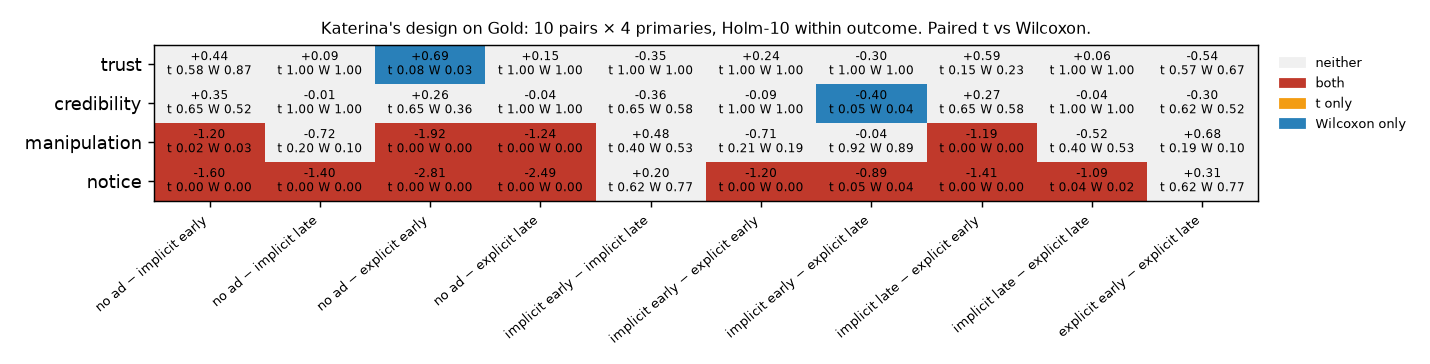

{'neither': 26, 'both': 12, 'Wilcoxon only': 2}


,outcome,pair_label,mean,dz,p_t_holm10,p_wilcoxon_holm10,verdict
2,trust,no ad − explicit early,0.685,0.376,0.078,0.029,Wilcoxon only
16,credibility,implicit early − explicit late,-0.395,-0.395,0.054,0.041,Wilcoxon only
20,manipulation,no ad − implicit early,-1.204,-0.422,0.022,0.028,both
22,manipulation,no ad − explicit early,-1.917,-0.972,0.000,0.000,both
23,manipulation,no ad − explicit late,-1.241,-0.533,0.002,0.005,both
27,manipulation,implicit late − explicit early,-1.194,-0.585,0.001,0.001,both
30,notice,no ad − implicit early,-1.602,-0.588,0.001,0.001,both
31,notice,no ad − implicit late,-1.398,-0.522,0.002,0.004,both
32,notice,no ad − explicit early,-2.806,-1.183,0.000,0.000,both
33,notice,no ad − explicit late,-2.491,-0.993,0.000,0.000,both


In [9]:
display(Image(ASSUMP / "pairwise_concordance.png"))
pw = pd.read_csv(ASSUMP / "pairwise_t_vs_wilcoxon.csv")
print(pw.verdict.value_counts().to_dict())
display(pw[pw.verdict != "neither"][["outcome", "pair_label", "mean", "dz", "p_t_holm10", "p_wilcoxon_holm10", "verdict"]].round(3))

## 3. Cued recall (ad grain, 216 rows → person \(D\))

Two \(D\) per outcome (no control cell). Explicit ads are remembered far better; the trust-shift item is lower after early ads.

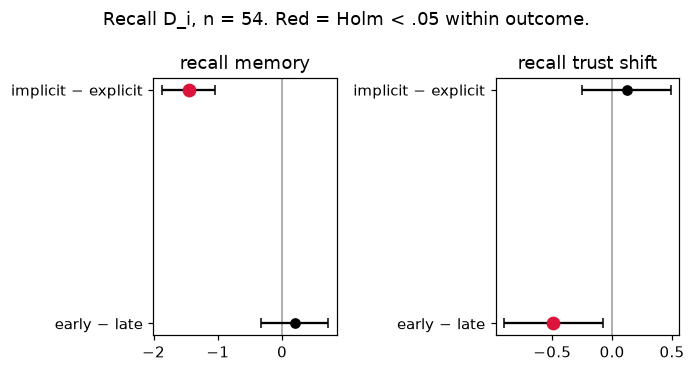

,outcome,contrast_label,mean,ci95_lo,ci95_hi,dz,p_raw,p_holm,holm_sig,p_wilcoxon
12,recall_memory,implicit − explicit,-1.454,-1.872,-1.036,-0.928,0.000,0.000,True,0.000
13,recall_memory,early − late,0.194,-0.333,0.722,0.098,0.473,0.473,False,0.656
14,recall_trust_shift,implicit − explicit,0.120,-0.249,0.489,0.087,0.525,0.525,False,0.572
15,recall_trust_shift,early − late,-0.491,-0.902,-0.079,-0.318,0.023,0.047,True,0.024


recall_memory       recall_trust_shift      
                        mean   std               mean   std
implicit early          4.35  2.36               4.19  1.85
implicit late           4.44  2.19               4.46  1.88
explicit early          6.09  1.39               3.85  2.16
explicit late           5.61  1.89               4.56  2.12

In [10]:
rec = conf[conf.family == "recall"]
display(viz.forest_D(rec, ["recall_memory", "recall_trust_shift"], "Recall D_i, n = 54. Red = Holm < .05 within outcome.")); plt.close()
display(rec[["outcome", "contrast_label", "mean", "ci95_lo", "ci95_hi", "dz", "p_raw", "p_holm", "holm_sig", "p_wilcoxon"]].round(3))
rd = ads.groupby("condition")[["recall_memory", "recall_trust_shift"]].agg(["mean", "std"]).reindex(sk.AD_CONDITIONS).round(2)
rd.index = [sk.LABEL[x] for x in rd.index]; display(rd)

## 4. The same matrix under Friedman + pairwise Wilcoxon

This is the sweep engine (notebook 02) restricted to the four primaries. Friedman over 5 conditions and over the 4 ad conditions; then all 10 pairs, Holm within the 10. For trust the omnibus is at .049 and one pair survives Holm: **no ad − explicit early**.

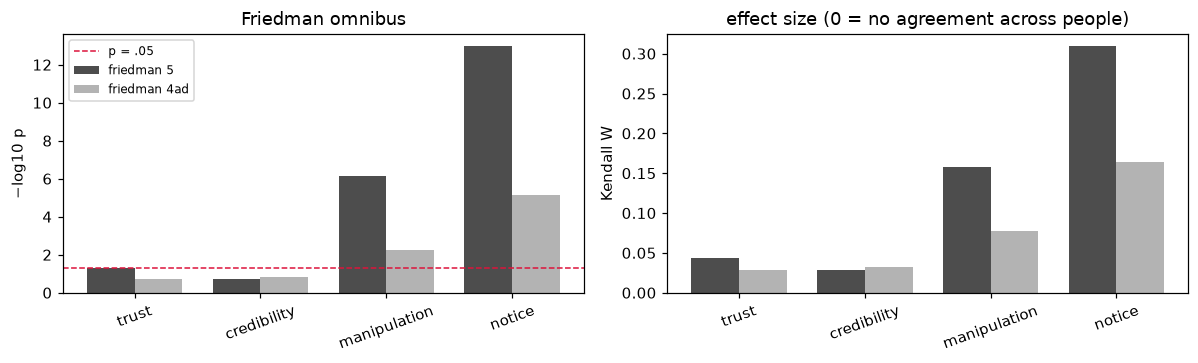

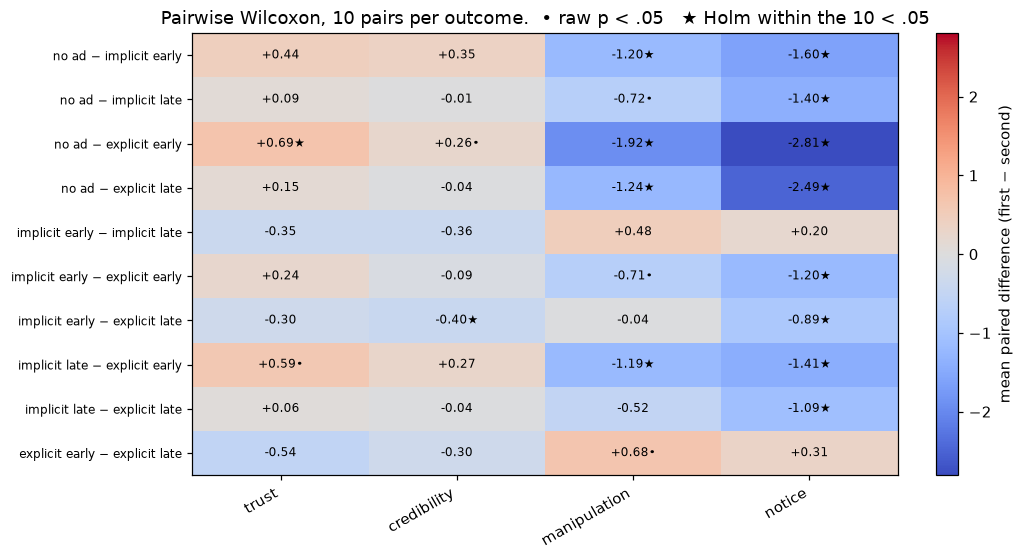

,outcome,test,n,stat,p_raw,kendall_w
164,credibility,friedman_4ad,54,5.2220,0.1562,0.0322
165,credibility,friedman_5,54,6.0347,0.1966,0.0279
200,manipulation,friedman_5,54,34.0739,0.0000,0.1577
201,manipulation,friedman_4ad,54,12.5196,0.0058,0.0773
236,notice,friedman_5,54,66.7490,0.0000,0.3090
237,notice,friedman_4ad,54,26.5011,0.0000,0.1636
272,trust,friedman_5,54,9.5462,0.0488,0.0442
273,trust,friedman_4ad,54,4.6618,0.1983,0.0288


In [11]:
sweep = pd.read_csv(SWEEP / "sweep_all_tests.csv")
display(viz.friedman_bars(sweep, PRIMARY)); plt.close()
display(viz.pairwise_heat(sweep, PRIMARY)); plt.close()
fr = sweep[(sweep.block == "friedman") & sweep.outcome.isin(PRIMARY)][["outcome", "test", "n", "stat", "p_raw", "kendall_w"]]
display(fr.round(4))

## 5. Model-based checks: ordinal GEE and random-intercept LMM

Why: the planned test treats a 1–7 answer as a number and the item is heavy-tailed. **Ordinal GEE** (proportional-odds logit, person as cluster, sandwich SE) for single items; **LMM** (random intercept per person) for composites and trust. Both adjust for arm, session position and task genre. Coefficients are odds of a *higher* answer (OR > 1 = higher), or points on the 1–7 scale.

Rebuild: `python analysis/walter/behavioural/stats/run_ordinal.py`.

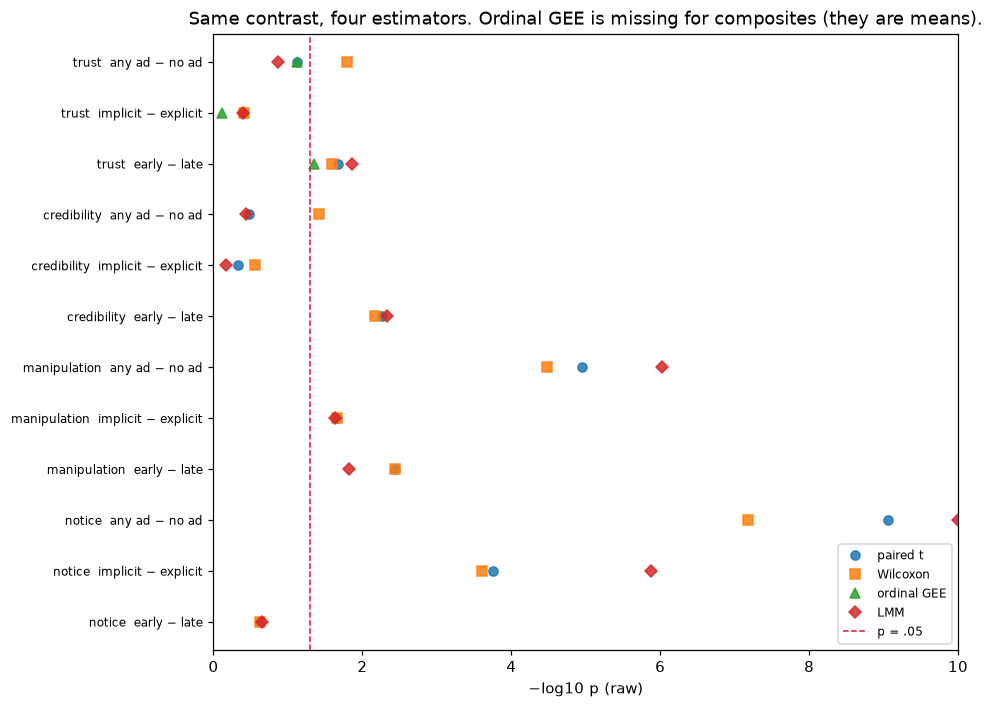

,outcome,contrast,contrast_label,D_mean,p_paired_t,p_holm_t,p_wilcoxon,OR,p_ordinal_gee,p_holm_gee,lmm_points,p_lmm,p_holm_lmm
0,trust,any_ad_vs_no_ads,any ad − no ad,-0.3426,0.0763,0.1526,0.0160,0.6786,0.0749,0.1499,-0.3131,0.1348,0.2695
1,trust,inline_vs_block,implicit − explicit,0.1481,0.4054,0.4054,0.3844,1.0553,0.7799,0.7799,0.1576,0.4013,0.4013
2,trust,early_vs_late,early − late,-0.4444,0.0210,0.0629,0.0258,0.6684,0.0441,0.1324,-0.4582,0.0138,0.0414
3,credibility,any_ad_vs_no_ads,any ad − no ad,-0.1404,0.3364,0.6728,0.0388,NaN,NaN,NaN,-0.1251,0.3604,0.7209
4,credibility,inline_vs_block,implicit − explicit,-0.0648,0.4752,0.6728,0.2780,NaN,NaN,NaN,-0.0494,0.6873,0.7209
5,credibility,early_vs_late,early − late,-0.3302,0.0055,0.0165,0.0068,NaN,NaN,NaN,-0.3440,0.0047,0.0140
6,manipulation,any_ad_vs_no_ads,any ad − no ad,1.2708,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.2918,0.0000,0.0000
7,manipulation,inline_vs_block,implicit − explicit,-0.6157,0.0222,0.0222,0.0221,NaN,NaN,NaN,-0.5358,0.0234,0.0304
8,manipulation,early_vs_late,early − late,0.5787,0.0036,0.0073,0.0036,NaN,NaN,NaN,0.5684,0.0152,0.0304
9,notice,any_ad_vs_no_ads,any ad − no ad,2.0741,0.0000,0.0000,0.0000,NaN,NaN,NaN,2.0756,0.0000,0.0000


In [12]:
side = pd.read_csv(ORD / "primary_four_engines.csv")
display(viz.four_engines(side)); plt.close()
display(side.round(4))

Read: the four estimators agree on manipulation, notice and credibility. On **trust any-ad** the Wilcoxon (.016) is the odd one out; paired \(t\), ordinal GEE and LMM all sit at .08–.13. On **trust early − late** the adjusted LMM reaches Holm .041, the GEE .13, the \(t\) .063.

Two levels, kept apart. **Confirmatory verdict:** at the pre-declared test (paired \(t\), Holm within outcome) trust has no surviving cell, so the freeze reports trust as null. **Sensitivity engines:** they split on early − late (LMM Holm .041, GEE .13, \(t\) .063; the Bayesian 95 % interval in §5b excludes 0 narrowly) and agree on any-ad (nothing). The reading is therefore "confirmatory null; sensitivity split on early − late", not "found". It does not get promoted into Results; it may be one sentence in Discussion.

The subject-specific Bayesian model (§5b) lands in the same place: any-ad OR 0.79 [0.47, 1.30]; early − late OR 0.59 [0.35, 0.96]; explicit early vs no ad OR 0.51 [0.26, 0.98]. Between-person spread is large (person SD ≈ 1.4 log-odds, i.e. ~4× odds per SD): who the person is matters far more than which condition they are in.

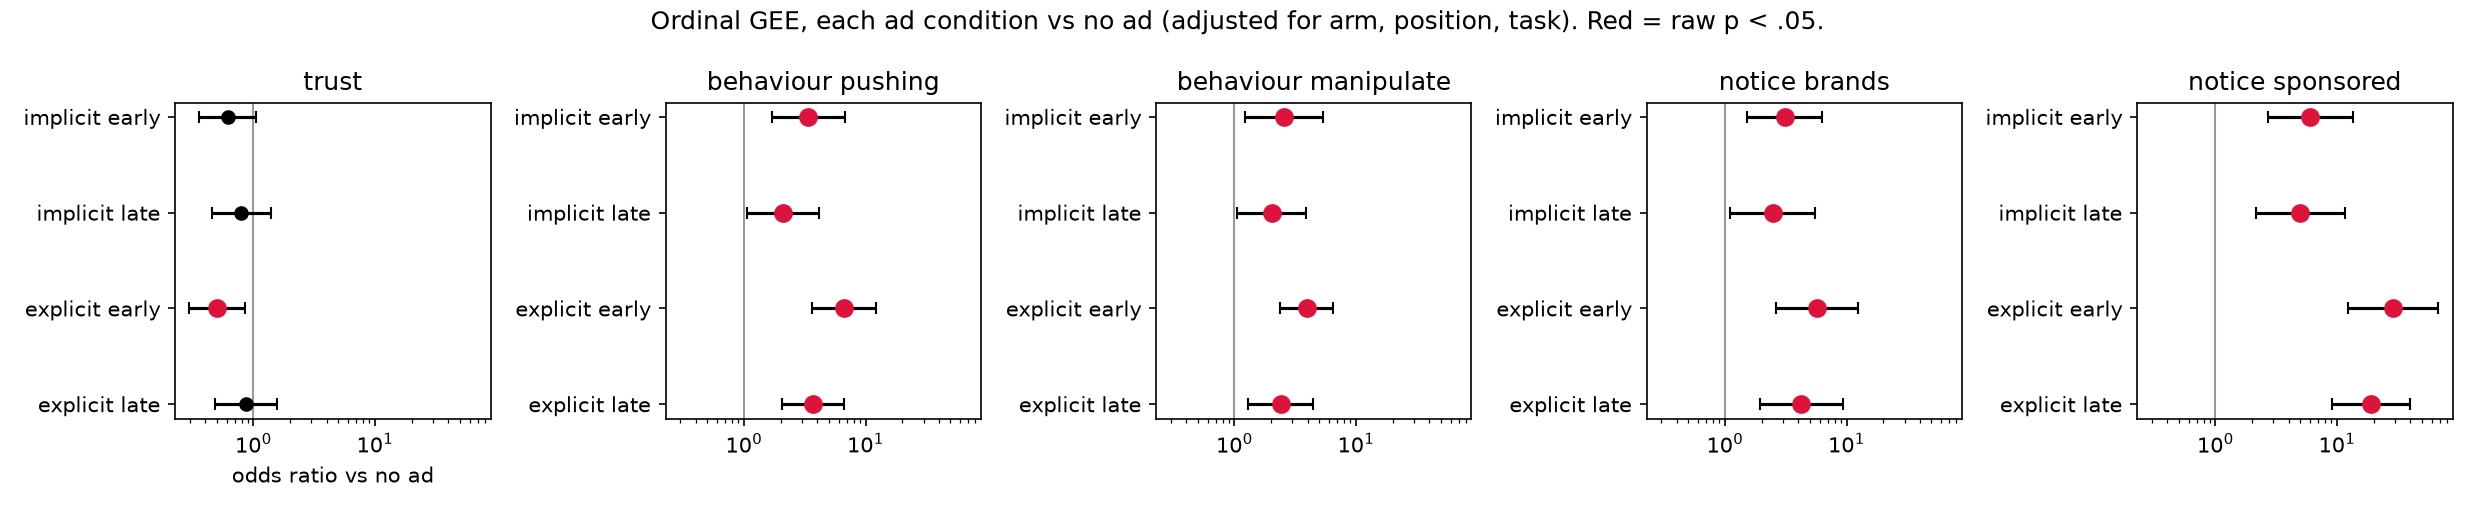

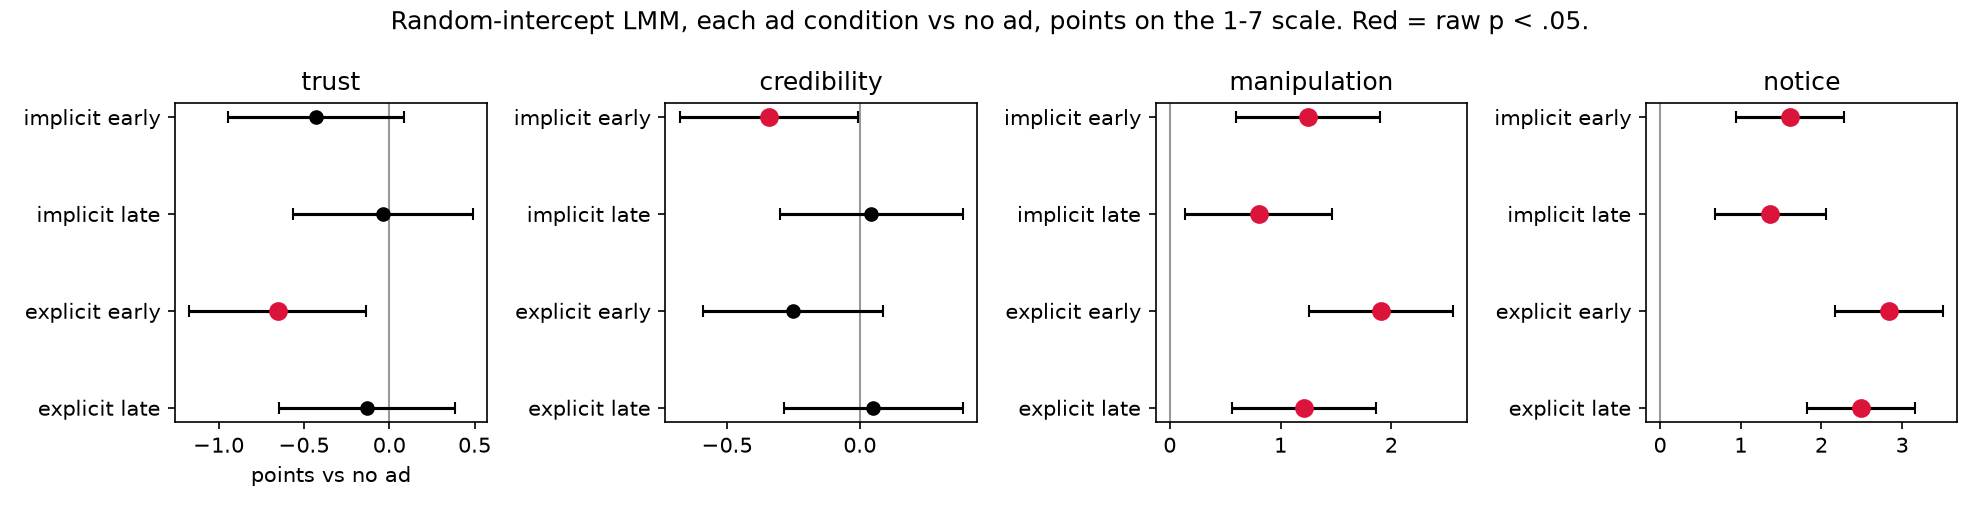

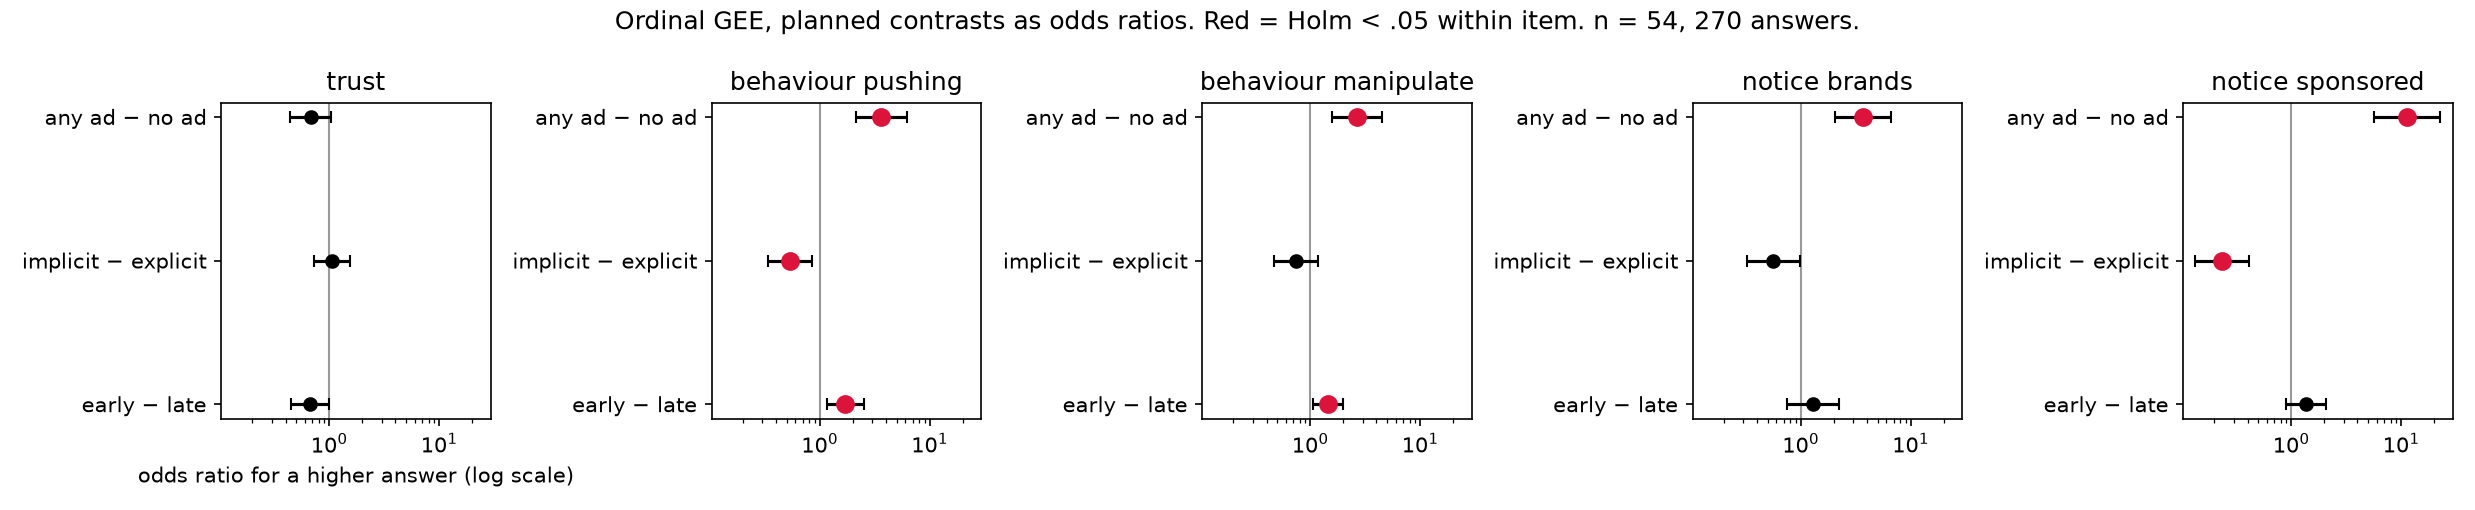

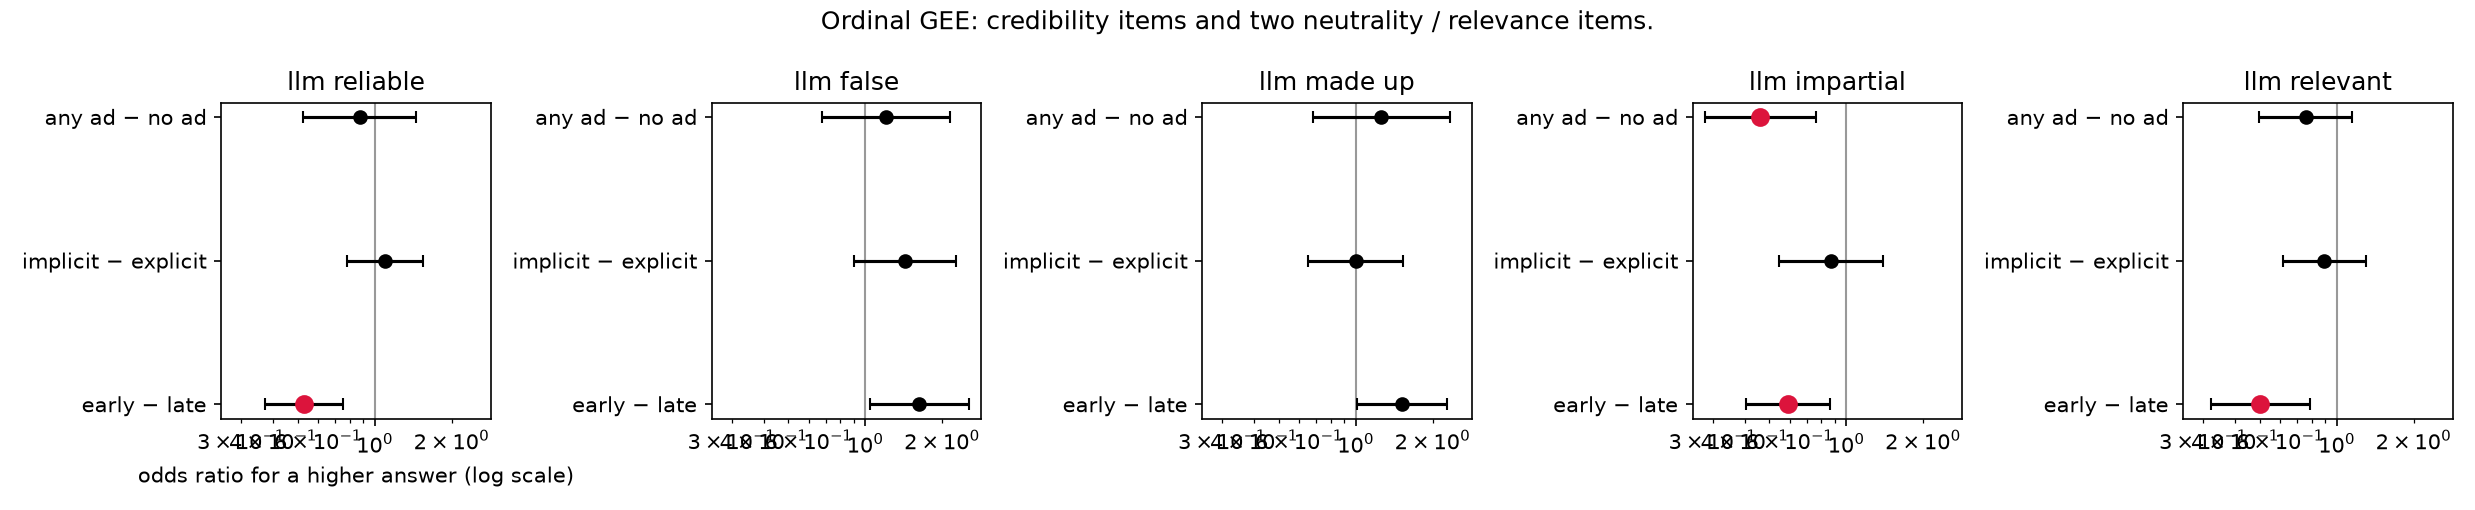

In [13]:
display(Image(ORD / "forest_or_conditions.png"))
display(Image(ORD / "forest_lmm_conditions.png"))
display(Image(ORD / "forest_or_items.png"))
display(Image(ORD / "forest_or_items_credibility.png"))

Each ad condition against no ad, adjusted. For trust only **explicit early** separates from control, in both engines. Item-level ORs: the sponsored-notice item moves 11× under ads; both manipulation items move 2.6–3.6×; the reliability, impartiality, relevance and convincingness items all fall early vs late.

In [14]:
mc = pd.read_csv(ORD / "model_contrasts.csv")
display(mc[(mc.engine == "ordinal_gee") & mc.holm_sig][["outcome", "contrast_label", "OR", "OR_lo", "OR_hi", "p_raw", "p_holm"]].round(3).reset_index(drop=True))

,outcome,contrast_label,OR,OR_lo,OR_hi,p_raw,p_holm
0,personality_influence,early − late,0.588,0.422,0.820,0.002,0.005
1,personality_changed_mind,implicit − explicit,0.557,0.385,0.805,0.002,0.006
2,behaviour_pushing,any ad − no ad,3.634,2.147,6.153,0.000,0.000
3,behaviour_pushing,implicit − explicit,0.534,0.336,0.848,0.008,0.011
4,behaviour_pushing,early − late,1.712,1.170,2.507,0.006,0.011
5,behaviour_manipulate,any ad − no ad,2.647,1.563,4.482,0.000,0.001
6,behaviour_manipulate,early − late,1.443,1.060,1.964,0.020,0.039
7,notice_brands,any ad − no ad,3.697,2.045,6.685,0.000,0.000
8,notice_sponsored,any ad − no ad,11.330,5.669,22.645,0.000,0.000
9,notice_sponsored,implicit − explicit,0.236,0.134,0.414,0.000,0.000


### 5b. Subject-specific ordinal model (Bayesian, random intercept per person)

The GEE above is population-averaged. This is the ordinal mixed model proper: ordered logit, one intercept per person, weakly informative priors, PyMC NUTS (4 chains, \(\hat R \le 1.002\), no divergences). `behaviour_pushing` is shown as a positive control so the eye can calibrate what a real effect looks like in the same model. Intervals are 95% equal-tailed posterior intervals; `P_lt_0` is the posterior probability that the effect is negative.

Rebuild: `python analysis/walter/behavioural/stats/run_bayes_ordinal.py`.

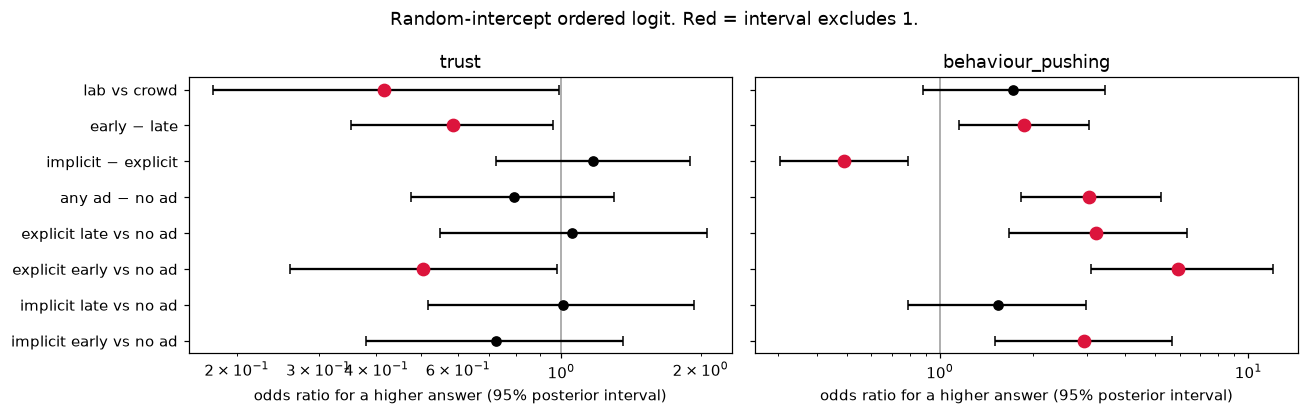

,outcome,label,OR,OR_lo,OR_hi,P_lt_0
0,trust,implicit early vs no ad,0.723,0.379,1.362,0.834
1,trust,implicit late vs no ad,1.010,0.518,1.940,0.496
2,trust,explicit early vs no ad,0.505,0.260,0.979,0.978
3,trust,explicit late vs no ad,1.056,0.547,2.065,0.431
4,trust,any ad − no ad,0.790,0.474,1.299,0.825
5,trust,implicit − explicit,1.170,0.725,1.898,0.257
6,trust,early − late,0.585,0.353,0.959,0.982
7,trust,lab vs crowd,0.416,0.178,0.989,0.976
8,trust,per session position,0.981,0.838,1.150,0.596
9,trust,person SD (log-odds),4.000,2.702,6.382,0.000


In [15]:
bo = pd.read_csv(ORD / "bayes_ordinal_random_intercept.csv")
show = bo[~bo.term.isin(["b_pos", "sigma_a"])]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, o in zip(axes, ["trust", "behaviour_pushing"]):
    b = show[show.outcome == o].reset_index(drop=True); y = np.arange(len(b))
    ax.axvline(1, color="0.6", lw=1)
    ax.errorbar(b.OR, y, xerr=[b.OR - b.OR_lo, b.OR_hi - b.OR], fmt="o", color="black", capsize=3)
    for yi, (lo, hi) in enumerate(zip(b.OR_lo, b.OR_hi)):
        if lo > 1 or hi < 1:
            ax.plot(b.OR[yi], yi, "o", color="crimson", ms=8, zorder=3)
    ax.set_xscale("log"); ax.set_yticks(y, b.label); ax.invert_yaxis(); ax.set_title(o)
    ax.set_xlabel("odds ratio for a higher answer (95% posterior interval)")
fig.suptitle("Random-intercept ordered logit. Red = interval excludes 1."); fig.tight_layout(); display(fig); plt.close()
display(bo[["outcome", "label", "OR", "OR_lo", "OR_hi", "P_lt_0"]].round(3))

## 6. Trust deep dive

Full printout and CSVs: `outputs/exploratory/trust/` (`stats/trust_deepdive.py`). Key facts: session order has no effect (Friedman over position .94); design is not perfectly position-balanced but with no position effect that does not move trust; trust \(D\) tracks credibility \(D\) (+.40) and manipulation \(D\) (−.40) and not notice \(D\) (−.09); no BFI trait moderates it; lab early − late is −0.75 (\(d_z=-0.61\)) at \(n=18\), crowd −0.29.

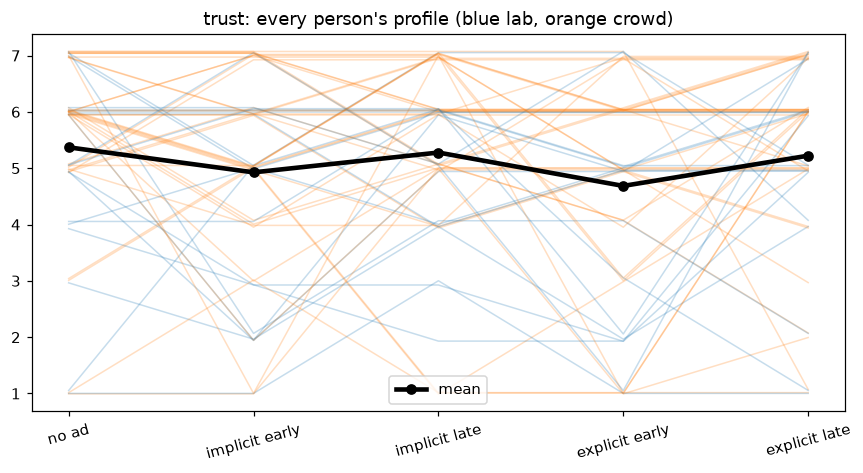

,arm,contrast,n,mean,ci95_lo,ci95_hi,dz,p_raw,p_wilcoxon
0,pooled,any ad − no ad,54,-0.343,-0.714,0.029,-0.246,0.076,0.016
1,pooled,implicit − explicit,54,0.148,-0.198,0.494,0.114,0.405,0.384
2,pooled,early − late,54,-0.444,-0.811,-0.078,-0.324,0.021,0.026
3,pooled,format × timing,54,0.093,-0.305,0.491,0.062,0.650,0.966
4,lab,any ad − no ad,18,-0.375,-1.182,0.432,-0.215,0.375,0.093
5,lab,implicit − explicit,18,0.083,-0.506,0.672,0.065,0.785,0.844
6,lab,early − late,18,-0.750,-1.317,-0.183,-0.611,0.019,0.027
7,lab,format × timing,18,0.083,-0.722,0.888,0.048,0.842,0.938
8,crowd,any ad − no ad,36,-0.326,-0.720,0.067,-0.271,0.113,0.081
9,crowd,implicit − explicit,36,0.181,-0.253,0.614,0.136,0.420,0.350


,pair_label,n,mean,rank_biserial,p_raw,p_holm_family
2,no ad − explicit early,54,0.685,0.544,0.003,0.029
7,implicit late − explicit early,54,0.593,0.445,0.025,0.228
9,explicit early − explicit late,54,-0.537,0.347,0.084,0.674
0,no ad − implicit early,54,0.444,0.288,0.125,0.874
4,implicit early − implicit late,54,-0.352,0.246,0.167,1.000
6,implicit early − explicit late,54,-0.296,0.188,0.305,1.000
5,implicit early − explicit early,54,0.241,0.160,0.370,1.000
1,no ad − implicit late,54,0.093,0.119,0.535,1.000
3,no ad − explicit late,54,0.148,0.023,0.894,1.000
8,implicit late − explicit late,54,0.056,0.022,0.904,1.000


In [16]:
display(viz.spaghetti(c, "trust")); plt.close()
tw = pd.read_csv(SWEEP / "trust" / "trust_planned_D_by_arm.csv"); display(tw.round(3))
pw = pd.read_csv(SWEEP / "trust" / "trust_pairwise_wilcoxon.csv")
display(pw[pw.arm == "pooled"][["pair_label", "n", "mean", "rank_biserial", "p_raw", "p_holm_family"]].sort_values("p_raw").round(3))

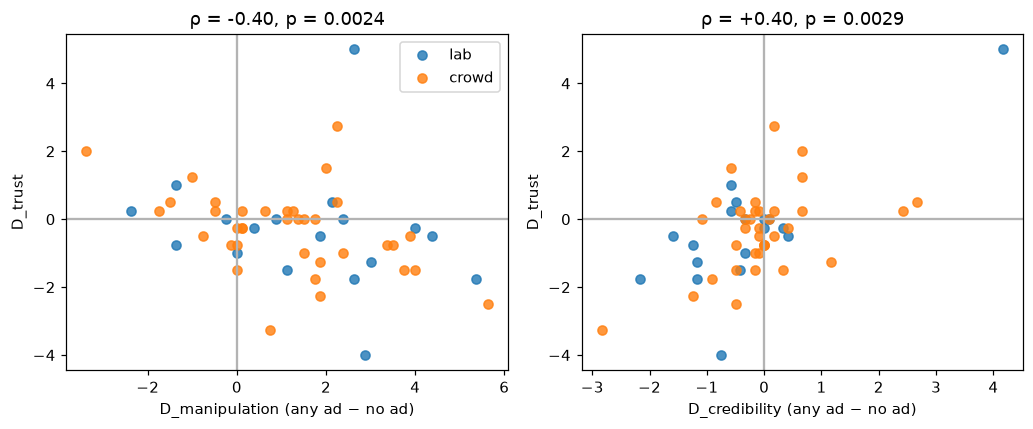

In [17]:
# who moved: trust D vs manipulation D and credibility D (any ad − no ad)
w_t = sk.wide(c, "trust"); w_m = sk.wide(c, "manipulation"); w_c = sk.wide(c, "credibility")
dd = pd.DataFrame({"D_trust": sk.contrast_scores(w_t, "any_ad_vs_no_ads"),
                   "D_manipulation": sk.contrast_scores(w_m, "any_ad_vs_no_ads"),
                   "D_credibility": sk.contrast_scores(w_c, "any_ad_vs_no_ads")}).join(person.set_index("experiment_id")["arm"])
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, other in zip(axes, ["D_manipulation", "D_credibility"]):
    for arm, col in viz.ARM_COLOR.items():
        s = dd[dd.arm == arm]; ax.scatter(s[other], s["D_trust"], color=col, alpha=0.8, label=arm)
    r = sk.spearman(dd[other], dd["D_trust"]); ax.axhline(0, color="0.7"); ax.axvline(0, color="0.7")
    ax.set_xlabel(other + " (any ad − no ad)"); ax.set_ylabel("D_trust"); ax.set_title(f"ρ = {r['rho']:+.2f}, p = {r['p_raw']:.4f}")
axes[0].legend(); fig.tight_layout(); display(fig); plt.close()

## 7. Checked / not checked

**Checked.** Roster (\(N=54\), crowdfail out, unfocused kept); lab scores match Katerina's table exactly; composites frozen before testing; planned \(D\) with paired \(t\) + Wilcoxon + Holm; Friedman (5, 4-ad); 10 pairwise Wilcoxon with Holm; ordinal GEE and LMM adjusted for arm / position / task; arm split; session-order drift; task genre; ceiling; sign counts; \(D\)–\(D\) correlations; BFI moderation; cued recall; the `ad_turn` Gold bug (block ads re-fire `ad_displayed`; fixed, tests unchanged).

**Not checked.** Single-item reliability for trust (impossible); the free-text "why" behind the trust item (free text is dropped); Bayesian ordinal mixed model (no PyMC / R here; GEE is population-averaged, not subject-specific); Hodges–Lehmann / trimmed estimates for the two outlier-driven trust cells; whether the early numeric-condition crowd sessions differ on trust; power beyond the CI.